In [3]:
# Jupyter Notebook: 분자 분석 및 시각화 파이프라인

# ======================
# 셀 1: 라이브러리 임포트
# ======================

import os
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, rdFMCS
from rdkit.DataStructs import TanimotoSimilarity

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA

# 시각화 스타일 설정
sns.set_style('whitegrid')

In [12]:
# ======================
# 헬퍼 함수: 유사도 히트맵 및 PCA 시각화
# ======================
def plot_heatmap(sim_matrix, ids, title, threshold=None, method='single'):
    """유사도 행렬에 대해 클러스터링 히트맵과 덴드로그램을 그립니다."""
    dist = 1.0 - sim_matrix
    condensed = squareform(dist, checks=False)
    Z = linkage(condensed, method=method)

    sns.clustermap(
        pd.DataFrame(sim_matrix, index=ids, columns=ids),
        row_linkage=Z, col_linkage=Z,
        cmap='vlag', figsize=(10,10)
    )
    plt.suptitle(title, y=1.02, fontsize=14)
    plt.show()

    if threshold is not None:
        plt.figure(figsize=(12,4))
        dendrogram(Z, no_labels=True)
        plt.axhline(y=threshold, color='red', linestyle='--')
        plt.title(f"Dendrogram (threshold={threshold})", fontsize=12)
        plt.xlabel('Distance')
        plt.ylabel('Cluster')
        plt.show()

        clusters = fcluster(Z, t=threshold, criterion='distance')
        counts = pd.Series(clusters).value_counts()
        print("Clusters (size > 5):")
        print(counts[counts > 5])


def plot_pca(sim_matrix, ids, inhibition, cmap='viridis', title='PCA on Similarity'):
    """유사도 행렬 기반 PCA 결과를 2D 산점도로 시각화합니다."""
    # PCA import가 셀 상단에 있어야 인식됩니다.
    pcs = PCA(n_components=2).fit_transform(sim_matrix)
    df_pca = pd.DataFrame(pcs, index=ids, columns=['PC1','PC2'])
    df_pca['Inhibition'] = inhibition

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=df_pca, x='PC1', y='PC2',
        hue='Inhibition', palette=cmap,
        edgecolor='none'
    )
    plt.title(title, fontsize=14)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(title='Inhibition', bbox_to_anchor=(1.05,1))
    plt.tight_layout()
    plt.show()

# MCS 유사도 계산 함수
def compute_mcs_similarity(mols):
    """리스트된 Mol 객체들 간 MCS 기반 Tanimoto 유사도 매트릭스를 계산합니다."""
    n = len(mols)
    sim = np.eye(n)
    for i in range(n-1):
        for j in range(i+1, n):
            res = rdFMCS.FindMCS([mols[i], mols[j]])
            na = res.numAtoms
            a1 = mols[i].GetNumAtoms(); a2 = mols[j].GetNumAtoms()
            sim_val = na / (a1 + a2 - na) if (a1 + a2 - na) > 0 else 0
            sim[i,j] = sim[j,i] = sim_val
    return sim

In [4]:
# ======================
# 셀 2: 데이터 로드 및 전처리
# ======================

import os
import pandas as pd
from rdkit import Chem

# 파일 경로 지정 (필요 시 수정)
file_path = " /summer_conference/open/CAS_clean.csv"

# 1) 파일 존재 여부 확인
if not os.path.exists(file_path):
    raise FileNotFoundError(f"❌ 파일을 찾을 수 없습니다: {file_path}")

# 2) CSV 파일 읽기 (인코딩 에러 방지용 cp1252 사용)
try:
    df_raw = pd.read_csv(file_path, encoding="cp1252")
except Exception as e:
    raise Exception(f"❌ 파일 읽기 중 오류 발생:\n{e}")

print(f"✅ 데이터 로드 완료: {df_raw.shape[0]}행, {df_raw.shape[1]}열")

# 3) SMILES 컬럼 존재 여부 확인
if 'SMILES' not in df_raw.columns:
    raise KeyError("❌ 'SMILES' 컬럼이 존재하지 않습니다. 컬럼명을 확인하세요.")

# 4) 안전한 Mol 변환 함수 정의
def safe_mol_from_smiles(smiles):
    if isinstance(smiles, str) and smiles.strip():
        try:
            return Chem.MolFromSmiles(smiles)
        except:
            return None
    return None

# 5) SMILES → Mol 변환
df_raw['mol'] = df_raw['SMILES'].apply(safe_mol_from_smiles)

# 6) 파싱 실패 수 확인
invalid = df_raw['mol'].isna().sum()
print(f"⚠️ SMILES 파싱 실패: {invalid}건")

# 7) 유효한 Mol만 필터링
df = df_raw.dropna(subset=['mol']).reset_index(drop=True)
print(f"✅ 유효한 분자 수: {df.shape[0]}행")

# 8) 파싱 실패 SMILES 샘플 출력
if invalid > 0:
    failed_df = df_raw[df_raw['mol'].isna()]
    print("❌ 파싱 실패 SMILES 예시:")
    print(failed_df[['SMILES']].head(10))


✅ 데이터 로드 완료: 3452행, 5열
⚠️ SMILES 파싱 실패: 13건
✅ 유효한 분자 수: 3439행
❌ 파싱 실패 SMILES 예시:
    SMILES
296    NaN
952    NaN
956    NaN
957    NaN
962    NaN
963    NaN
964    NaN
965    NaN
968    NaN
970    NaN


In [5]:
# ======================
# Assay Parameter 유형 확인
# ======================

# 1. 고유값 개수 확인
type_counts = df['Assay Parameter'].value_counts(dropna=False)

# 2. 전체 요약 출력
print("🔍 'Assay Parameter' 열의 고유값 개수:")
print(type_counts)

# 3. IC50 vs 기타
ic50_count = type_counts.get('IC50', 0)
other_count = type_counts.sum() - ic50_count

print(f"\n✅ IC50 개수: {ic50_count}")
print(f"✅ 다른 타입 개수: {other_count}")

# 4. IC50 외 타입 목록
other_types = type_counts[type_counts.index != 'IC50']
print("\n📌 IC50 외 다른 타입들:")
for assay_type, count in other_types.items():
    print(f"• {assay_type}: {count}개")

# EC50을 제외한 데이터만 남기기
df_filtered = df[df['Assay Parameter'] != 'EC50'].reset_index(drop=True)

print(f"✅ EC50 제거 완료: {df_filtered.shape[0]}개 데이터 남음")
print(f"🧪 남은 Assay Parameter 종류:\n{df_filtered['Assay Parameter'].value_counts()}")



🔍 'Assay Parameter' 열의 고유값 개수:
Assay Parameter
IC50    2844
EC50     595
Name: count, dtype: int64

✅ IC50 개수: 2844
✅ 다른 타입 개수: 595

📌 IC50 외 다른 타입들:
• EC50: 595개
✅ EC50 제거 완료: 2844개 데이터 남음
🧪 남은 Assay Parameter 종류:
Assay Parameter
IC50    2844
Name: count, dtype: int64


In [6]:
from rdkit.Chem import Descriptors, rdMolDescriptors

def featurize_full(mol):
    """단일 분자에 대한 통합 피처 계산"""
    feats = {
        'MolWt': Descriptors.MolWt(mol),
        'MolLogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
        'NumValenceElectrons': Descriptors.NumValenceElectrons(mol),
        'HeavyAtomCount': Descriptors.HeavyAtomCount(mol),
        'NumAliphaticRings': Descriptors.NumAliphaticRings(mol),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
        'NumRings': rdMolDescriptors.CalcNumRings(mol),
        'NumCharges': sum(a.GetFormalCharge() != 0 for a in mol.GetAtoms()),
        'NumCarbonAtoms': sum(a.GetSymbol() == 'C' for a in mol.GetAtoms())
    }

    # 주요 원소 개수
    atom_types = ['C', 'H', 'N', 'O', 'Cl', 'S', 'F', 'Br', 'I', 'B', 'Si']
    for atom in atom_types:
        feats[f'Num_{atom}'] = sum(a.GetSymbol() == atom for a in mol.GetAtoms())

    # 기능성 그룹 SMARTS 패턴
    fg_smarts = {
        'Amine_primary': '[NX3;H2]',
        'Amine_secondary': '[NX3;H1]',
        'Amine_tertiary': '[NX3;H0]',
        'Alcohol': '[OX2H]',
        'Aldehyde': '[CX3H1](=O)[#6]',
        'Ketone': '[#6][CX3](=O)[#6]',
        'Carboxylic_acid': '[CX3](=O)[OX2H1]',
        'Ester': '[CX3](=O)[OX2][#6]',
        'Nitrile': '[CX2]#N'
    }
    for name, patt in fg_smarts.items():
        smarts = Chem.MolFromSmarts(patt)
        feats[f'FG_{name}'] = len(mol.GetSubstructMatches(smarts))

    return feats

# 피처 추출 및 병합
full_feats = [featurize_full(mol) for mol in df['mol']]
full_feat_df = pd.DataFrame(full_feats)

# 결과 통합: SMILES, pIC50, 피처
df_features = pd.concat([df[['SMILES', 'pX Value']], full_feat_df], axis=1)

# 결과 확인
print(df_features.head())
print(f"전체 피처 매트릭스 크기: {df_features.shape}")


                                              SMILES  pX Value    MolWt  \
0  O[C@H]1[C@H](N2C=3C(N=C2)=C(N)N=CN3)O[C@H](COP...   5.61380  507.182   
1                         S(C)C1=C2C(=NC(N)=N1)N=CN2   4.87615  181.224   
2                  N(C1=C2C(N=CN2)=NC=N1)C3=CC=CC=C3   5.00000  211.228   
3                        C12=C(N=CN=C1N=CN2)N3CCCCC3   4.76955  203.249   
4   C(C)(=O)C1=C2C=3C(C(=O)C=4C2=CC=CC4)=CC=CC3NC1=O   4.82391  289.290   

   MolLogP    TPSA  NumHDonors  NumHAcceptors  NumRotatableBonds  \
0  -1.6290  279.13           7             14                  8   
1   0.6570   80.48           2              5                  1   
2   2.0965   66.49           2              4                  2   
3   1.3432   57.70           1              4                  1   
4   2.9421   67.00           1              3                  1   

   NumValenceElectrons  HeavyAtomCount  ...  Num_Si  FG_Amine_primary  \
0                  174              31  ...       0                

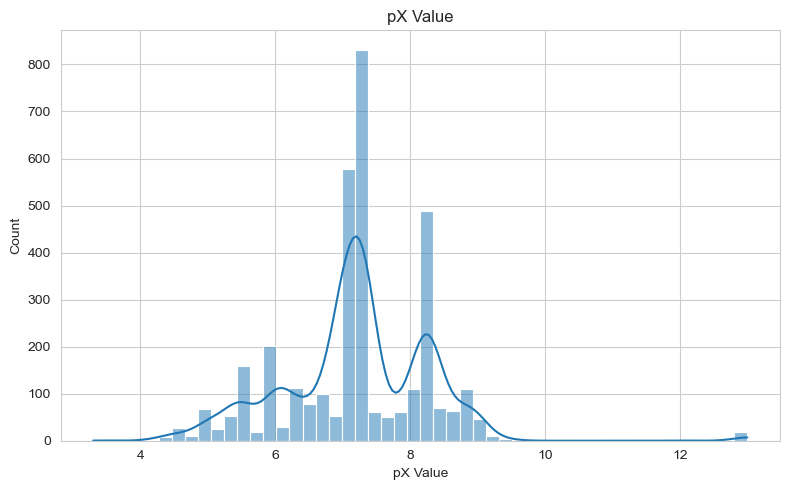

In [7]:
# ======================
# 셀 4a: EDA - pX Value
# ======================
plt.figure(figsize=(8,5))
sns.histplot(df_raw['pX Value'], bins=50, kde=True)
plt.title('pX Value')
plt.xlabel('pX Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [8]:
# ======================
#  Morgan 지문 생성
# ======================
def get_morgan_fp(mol, radius=2, nBits=2048):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)

fps_morgan=[get_morgan_fp(m) for m in df['mol']]
print(f"Morgan fingerprints: {len(fps_morgan)}개, 길이={fps_morgan[0].GetNumBits()}")
fps_array=np.array([list(fp) for fp in fps_morgan])

# 첫 5개의 지문 출력 (각 지문은 2048 비트 벡터)
for i in range(5):
    print(f"\n[Molecule {i+1}]")
    print(fps_array[i])

# 또는 DataFrame으로 보기 좋게 출력 (선택)
fps_df = pd.DataFrame(fps_array[:5])
print("\n▶️ 지문 (앞 5개):")
display(fps_df)


[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerator
[15:03:12] DEPRECATION WARNING: please use MorganGenerat

Morgan fingerprints: 3439개, 길이=2048

[Molecule 1]
[0 0 0 ... 0 0 0]

[Molecule 2]
[0 0 0 ... 0 0 0]

[Molecule 3]
[0 0 0 ... 0 0 0]

[Molecule 4]
[0 0 1 ... 0 0 0]

[Molecule 5]
[0 1 0 ... 0 0 0]

▶️ 지문 (앞 5개):


,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


/var/folders/2q/v_79vqld72sf48ghq2z01j2m0000gn/T/ipykernel_88130/2409247184.py:27: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/Users/oseli/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


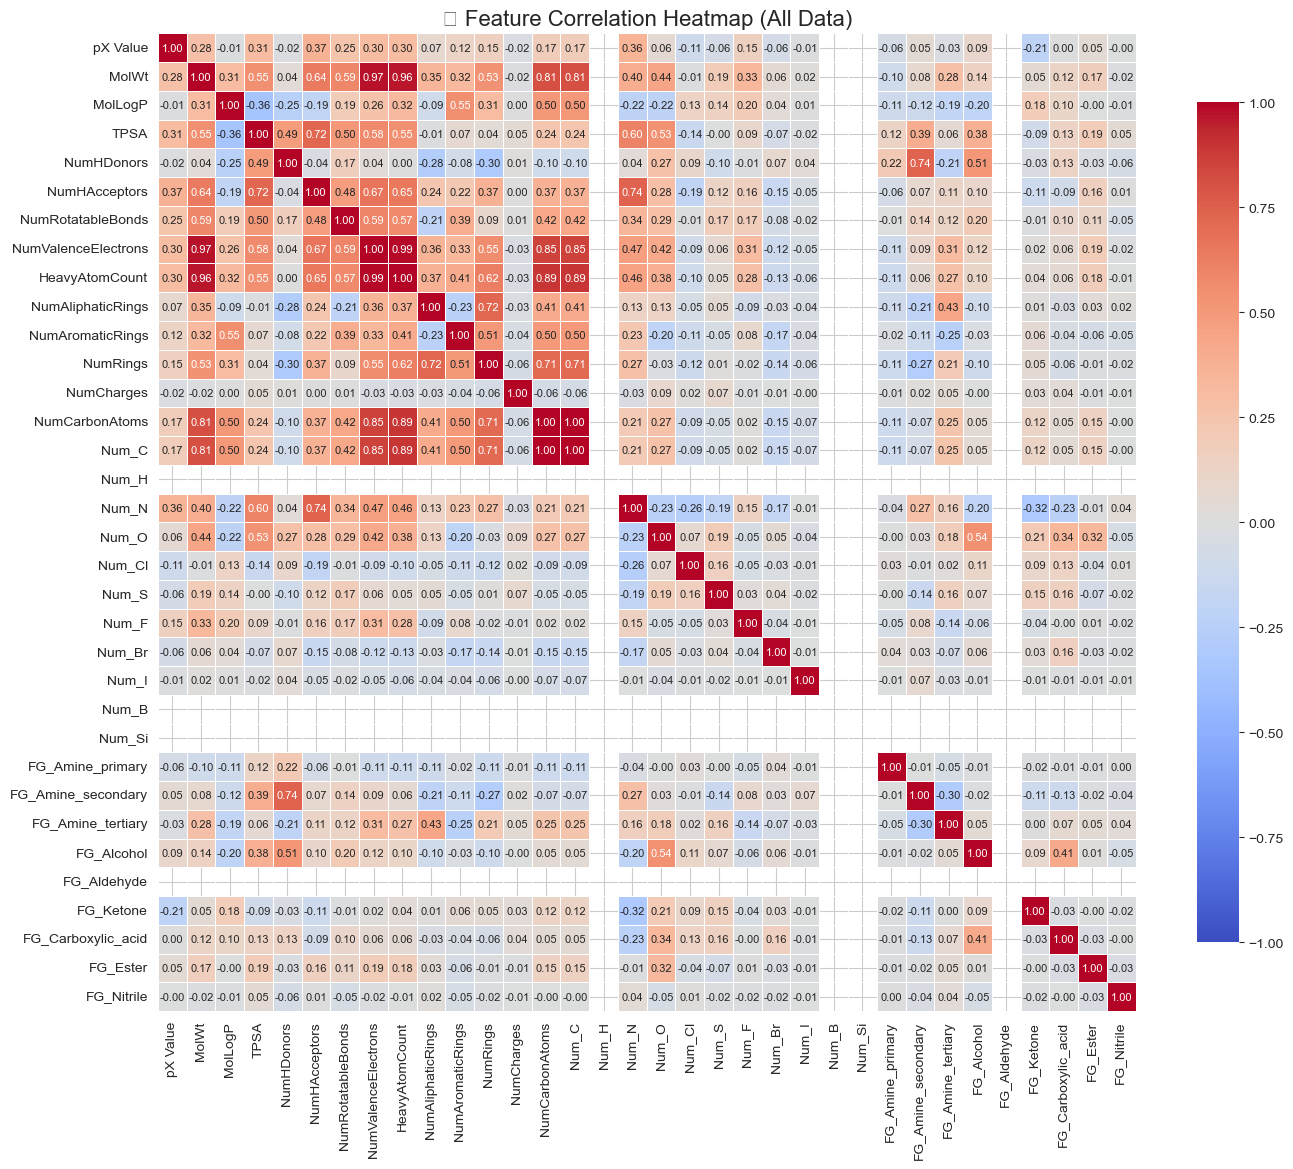

/var/folders/2q/v_79vqld72sf48ghq2z01j2m0000gn/T/ipykernel_88130/2409247184.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_pX.values, y=corr_with_pX.index, palette='coolwarm')
/var/folders/2q/v_79vqld72sf48ghq2z01j2m0000gn/T/ipykernel_88130/2409247184.py:34: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/Users/oseli/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


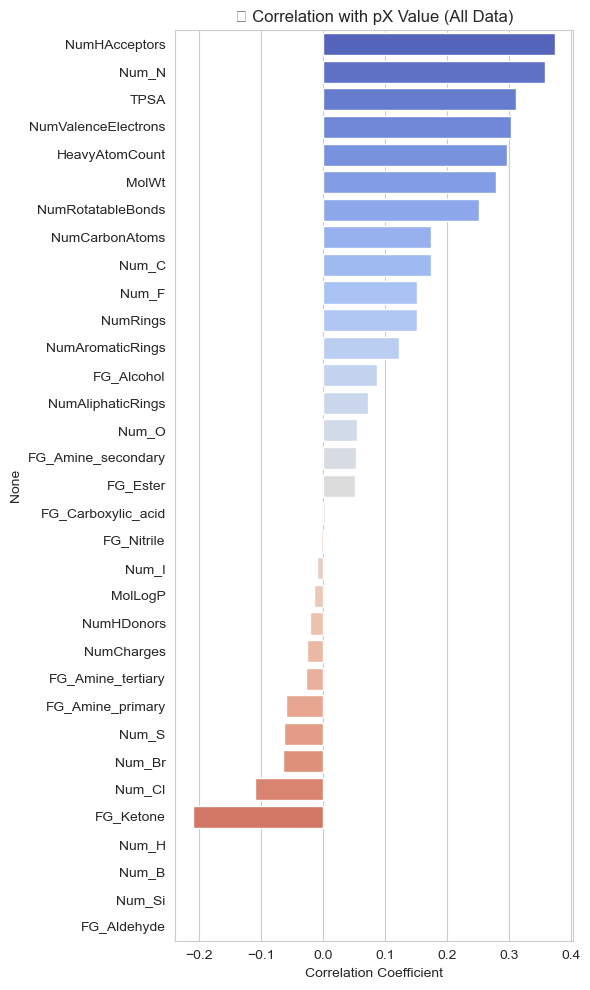

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 수치형 컬럼만 선택
numeric_cols = df_features.select_dtypes(include=[np.number])

# 상관 행렬 계산
corr_matrix = numeric_cols.corr()

# pX Value가 포함되어 있는지 확인
if 'pX Value' not in corr_matrix.columns:
    raise ValueError("❌ 'pX Value' 컬럼이 상관 행렬에 없습니다. 컬럼명을 확인하세요.")

# pX Value와의 상관계수만 추출 (자기 자신 제외)
corr_with_pX = corr_matrix['pX Value'].drop(labels=['pX Value']).sort_values(ascending=False)

# 히트맵
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, 
            annot=True, fmt=".2f", cmap="coolwarm", 
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})

plt.title("📊 Feature Correlation Heatmap (All Data)", fontsize=16)
plt.tight_layout()
plt.show()
# 바 차트
plt.figure(figsize=(6, 10))
sns.barplot(x=corr_with_pX.values, y=corr_with_pX.index, palette='coolwarm')
plt.title("📈 Correlation with pX Value (All Data)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()


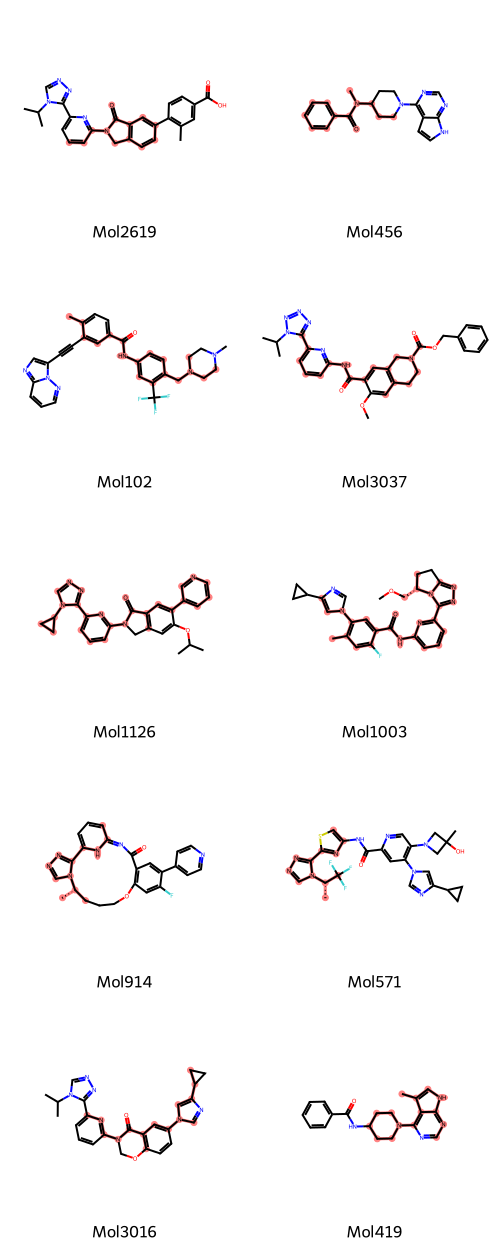

In [10]:
# ======================
# 셀 7: MCS 샘플링 및 시각화
# ======================
random.seed(42)
pairs=[tuple(random.sample(range(len(df)),2)) for _ in range(5)]

mols,highlights,legends=[],[],[]
for i,j in pairs:
    m1,m2=df.loc[i,'mol'],df.loc[j,'mol']
    res=rdFMCS.FindMCS([m1,m2])
    mcs_mol=Chem.MolFromSmarts(res.smartsString)
    match1=m1.GetSubstructMatch(mcs_mol)
    match2=m2.GetSubstructMatch(mcs_mol)
    mols+=[m1,m2]
    highlights+=[list(match1),list(match2)]
    legends+=[f"Mol{i}",f"Mol{j}"]

from rdkit.Chem.Draw import MolsToGridImage
img=MolsToGridImage(mols,highlightAtomLists=highlights,molsPerRow=2,subImgSize=(250,250),legends=legends)
display(img)

In [ ]:
# ======================
# 셀 8: MCS 기반 유사도 클러스터링 & 히트맵
# ======================
# mol_list 전체 데이터 Mol 객체 리스트로 설정
mol_list = df['mol']
ids = df.index.astype(str).tolist()  # 전체 인덱스를 문자열 ID로 사용

print("🔄 MCS 유사도 행렬을 전체 데이터로 새로 계산 중...")
sim_mcs = compute_mcs_similarity(mol_list)

# 결과 저장 (선택적으로 저장)
mcs_npy = 'fmcs_tanimoto_full_new.npy'
mcs_csv = 'fmcs_tanimoto_full_new.csv'
np.save(mcs_npy, sim_mcs)
pd.DataFrame(sim_mcs, index=ids, columns=ids).to_csv(mcs_csv)

# 히트맵 시각화
plot_heatmap(sim_mcs, ids, title='🔬 MCS-based Tanimoto Similarity (full dataset)', threshold=0.34)
